In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler, label_binarize
from sklearn.svm import LinearSVC, SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, cross_val_predict

In [13]:
data1 = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Data/B2_1_z_scored.csv")
data2 = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Data/B2_2_z_scored.csv")

data = pd.concat([data1, data2])
data = data.iloc[:,1:]

y = data.iloc[:,3]
X = data.iloc[:,4:]

              precision    recall  f1-score   support

         0.0       0.95      0.62      0.75      3538
         1.0       0.20      0.45      0.28       295
         2.0       0.03      0.30      0.05        88

    accuracy                           0.60      3921
   macro avg       0.39      0.46      0.36      3921
weighted avg       0.88      0.60      0.70      3921

Accuracy: 0.6044376434583014


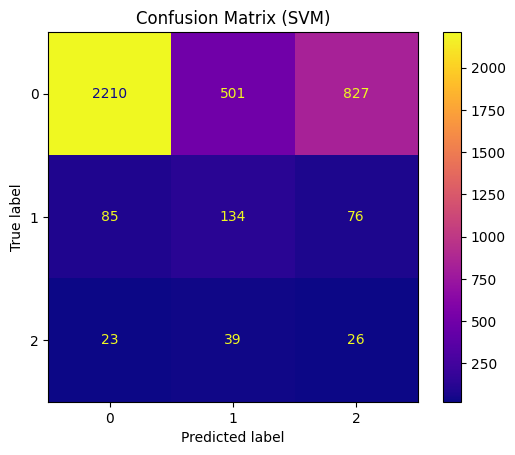

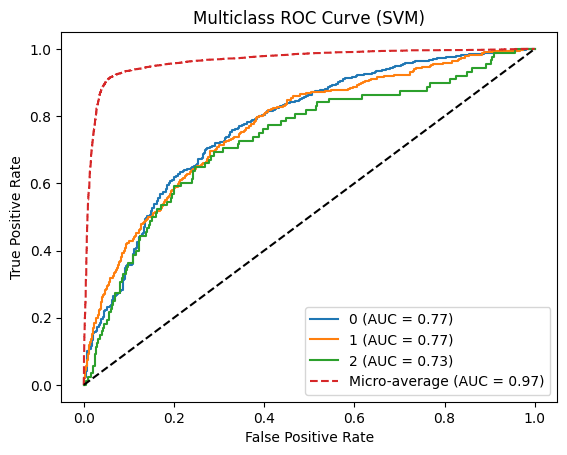

Macro AUC: 0.759
Micro AUC: 0.966


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=42)

C = 1
gamma = 0.01
clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=C, gamma=gamma, decision_function_shape='ovr', class_weight='balanced', probability=True))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", clf.score(X_test, y_test))

labels = [0, 1, 2]
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='plasma')
plt.title('Confusion Matrix (SVM)')
plt.show()

y_test_bin = label_binarize(y_test, classes=labels)

y_score = clf.predict_proba(X_test)

n_classes = len(labels)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())

roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

macro_auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr', average='macro')

plt.figure()

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{labels[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot(fpr["micro"], tpr["micro"], linestyle='--', label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (SVM)')
plt.legend()
plt.show()

print(f"Macro AUC: {macro_auc:.3f}")
print(f"Micro AUC: {roc_auc['micro']:.3f}")


accuracy: 0.626 ± 0.012
precision_macro: 0.392 ± 0.005
recall_macro: 0.456 ± 0.017
f1_macro: 0.365 ± 0.006


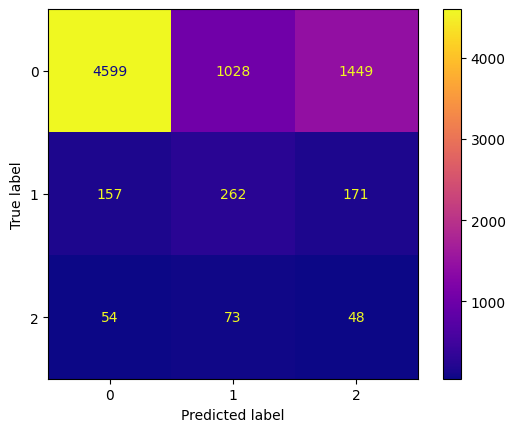

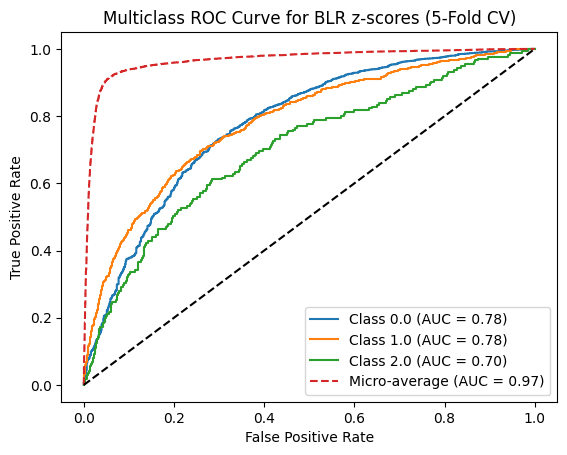

Macro AUC: 0.754
Micro AUC: 0.966


In [15]:
C = 1
gamma = 0.01

clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=C, gamma=gamma, decision_function_shape='ovr', class_weight='balanced', probability=True))

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision_macro': make_scorer(precision_score, average='macro'),
    'recall_macro': make_scorer(recall_score, average='macro'),
    'f1_macro': make_scorer(f1_score, average='macro')}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    clf, X, y, cv=cv, scoring=scoring,
    return_train_score=False, return_estimator=True
)

for metric in scoring.keys():
    print(f"{metric}: {np.mean(cv_results[f'test_{metric}']):.3f} ± {np.std(cv_results[f'test_{metric}']):.3f}")

y_pred = cross_val_predict(clf, X, y, cv=cv)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='plasma')
plt.show()


y_score = cross_val_predict(
    clf, X, y, cv=cv, method='predict_proba'
)

classes = np.unique(y)
y_bin = label_binarize(y, classes=classes)

n_classes = y_bin.shape[1]

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(
    y_bin.ravel(), y_score.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

macro_auc = roc_auc_score(
    y_bin, y_score, multi_class='ovr', average='macro'
)


plt.figure()

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot(fpr["micro"], tpr["micro"],
         linestyle='--',
         label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve for BLR z-scores (5-Fold CV)')
plt.legend()
plt.show()

print(f"Macro AUC: {macro_auc:.3f}")
print(f"Micro AUC: {roc_auc['micro']:.3f}")

              precision    recall  f1-score   support

         1.0       0.85      0.69      0.76       121
         2.0       0.31      0.53      0.39        32

    accuracy                           0.65       153
   macro avg       0.58      0.61      0.57       153
weighted avg       0.73      0.65      0.68       153

Accuracy: 0.6535947712418301


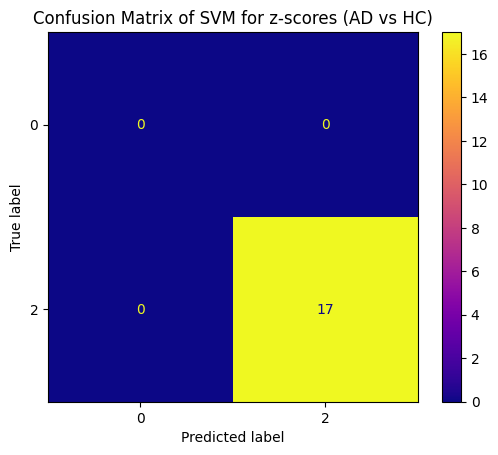

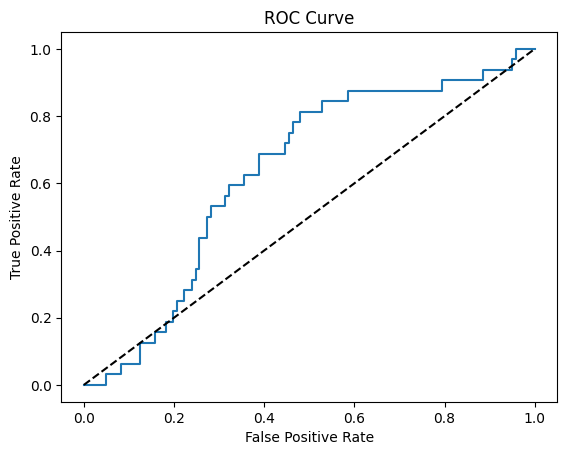

In [18]:
######################
###### AD VS HC ######
######################

ad_vs_hc = data[data["Diagnosis"] != 1]
ad_vs_hc = ad_vs_hc.iloc[:,1:]

y = ad_vs_mci.iloc[:,0]
X = ad_vs_mci.iloc[:,1:]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

C = 1
clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=C, gamma=gamma, decision_function_shape='ovr', class_weight='balanced', probability=True))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", clf.score(X_test, y_test))

labels = [0, 2]
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='plasma')
plt.title('Confusion Matrix of SVM for z-scores (AD vs HC)')
plt.show()

y_test_binary = (y_test == 2).astype(int)  # AD as positive class
y_pred_binary = (y_pred == 2).astype(int)  # 
y_score = clf.predict_proba(X_test)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test_binary, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()


              precision    recall  f1-score   support

         1.0       0.82      0.89      0.85       121
         2.0       0.38      0.25      0.30        32

    accuracy                           0.76       153
   macro avg       0.60      0.57      0.58       153
weighted avg       0.73      0.76      0.74       153

Accuracy: 0.7581699346405228


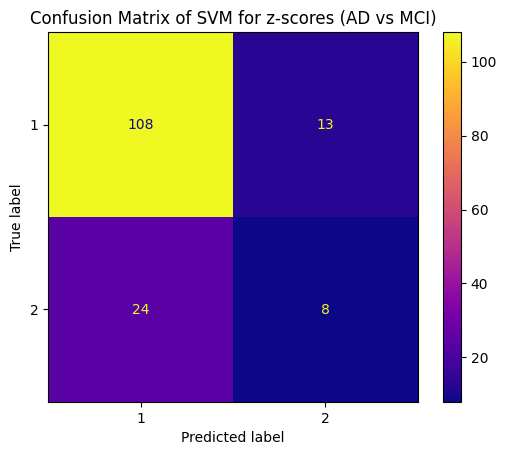

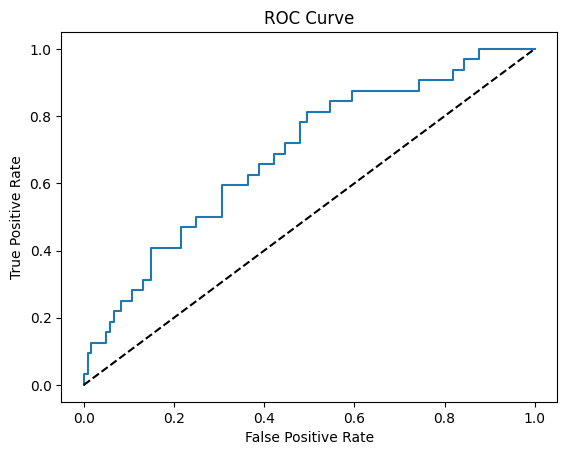

In [12]:
######################
##### AD VS MCI #####
######################

ad_vs_mci = data[data["Diagnosis"] != 0]
ad_vs_mci = ad_vs_mci.iloc[:,1:]

y = ad_vs_mci.iloc[:,0]
X = ad_vs_mci.iloc[:,1:]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

C = 2
gamma = 0.01
clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=C, gamma=gamma, decision_function_shape='ovo', class_weight='balanced', probability=True))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", clf.score(X_test, y_test))


labels = [1, 2]
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='plasma')
plt.title('Confusion Matrix of SVM for z-scores (AD vs MCI)')
plt.show()

y_test_binary = (y_test == 2).astype(int)  # AD as positive class
y_pred_binary = (y_pred == 2).astype(int)  
y_score = clf.predict_proba(X_test)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test_binary, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

              precision    recall  f1-score   support

         0.0       0.99      0.73      0.84      7083
         1.0       0.04      0.66      0.08       121

    accuracy                           0.73      7204
   macro avg       0.52      0.70      0.46      7204
weighted avg       0.98      0.73      0.83      7204

Accuracy: 0.7282065519156025


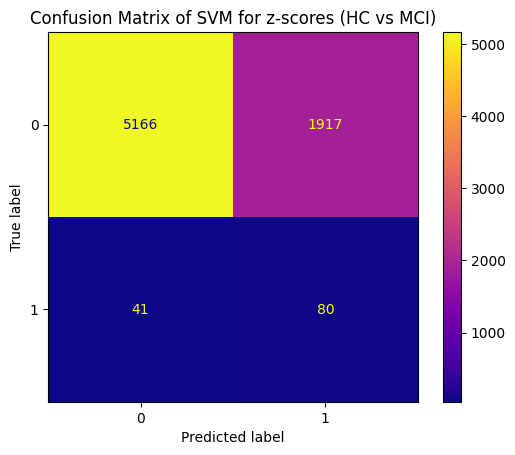

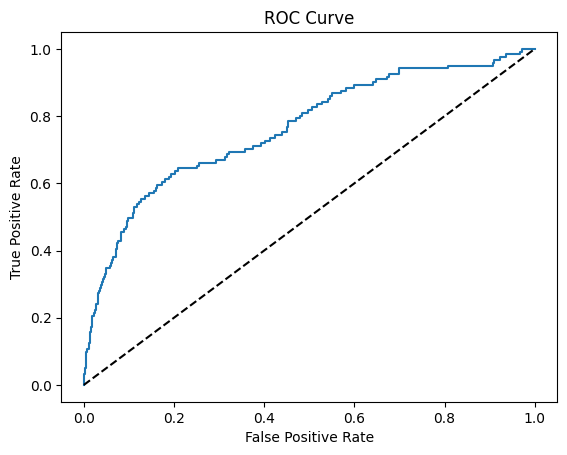

In [17]:
######################
###### MCI VS HC ######
######################


hc_vs_mci = data[data["Diagnosis"] != 2]
hc_vs_mci = hc_vs_mci.iloc[:,1:]

y = hc_vs_mci.iloc[:,0]
X = hc_vs_mci.iloc[:,1:]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

C = 2
gamma = 0.01
labels = [0, 1]
clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=C, gamma=gamma, decision_function_shape='ovo', class_weight='balanced', probability=True))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", clf.score(X_test, y_test))

cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='plasma')
plt.title('Confusion Matrix of SVM for z-scores (HC vs MCI)')
plt.show()

y_test_binary = (y_test == 1).astype(int)  # MCI as positive class
y_pred_binary = (y_pred == 1).astype(int)  # 
y_score = clf.predict_proba(X_test)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test_binary, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()